<a href="https://colab.research.google.com/github/HELLOI9/Machine-Learning/blob/master/%E2%80%9CML2021Spring_HW1_ipynb%E2%80%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 1: COVID-19 Cases Prediction (Regression)**

Author: Heng-Jui Chang

Slides: https://github.com/ga642381/ML2021-Spring/blob/main/HW01/HW01.pdf  
Videos (Mandarin): https://cool.ntu.edu.tw/courses/4793/modules/items/172854  
https://cool.ntu.edu.tw/courses/4793/modules/items/172853  
Video (English): https://cool.ntu.edu.tw/courses/4793/modules/items/176529


Objectives:
* Solve a regression problem with deep neural networks (DNN).
* Understand basic DNN training tips.
* Get familiar with PyTorch.

If any questions, please contact the TAs via TA hours, NTU COOL, or email.


# **Download Data**


If the Google drive links are dead, you can download data from [kaggle](https://www.kaggle.com/c/ml2021spring-hw1/data), and upload data manually to the workspace.

In [99]:
tr_path = 'covid.train.csv'  # path to training data
tt_path = 'covid.test.csv'   # path to testing data

# **Import Some Packages**

In [100]:
# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# For data preprocess
import numpy as np
import csv
import os

# For plotting
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

myseed = 42069  # set a random seed for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

# **Some Utilities**

You do not need to modify this part.

In [101]:
def get_device():
    ''' Get device (if GPU is available, use GPU) '''
    return 'cuda' if torch.cuda.is_available() else 'cpu'

def plot_learning_curve(loss_record, title=''):
    ''' Plot learning curve of your DNN (train & dev loss) '''
    total_steps = len(loss_record['train'])
    x_1 = range(total_steps)
    x_2 = x_1[::len(loss_record['train']) // len(loss_record['dev'])]
    figure(figsize=(6, 4))
    plt.plot(x_1, loss_record['train'], c='tab:red', label='train')
    plt.plot(x_2, loss_record['dev'], c='tab:cyan', label='dev')
    plt.ylim(0.0, 5.)
    plt.xlabel('Training steps')
    plt.ylabel('MSE loss')
    plt.title('Learning curve of {}'.format(title))
    plt.legend()
    plt.show()


def plot_pred(dv_set, model, device, lim=35., preds=None, targets=None):
    ''' Plot prediction of your DNN '''
    if preds is None or targets is None:
        model.eval()
        preds, targets = [], []
        for x, y in dv_set:
            x, y = x.to(device), y.to(device)
            with torch.no_grad():
                pred = model(x)
                preds.append(pred.detach().cpu())
                targets.append(y.detach().cpu())
        preds = torch.cat(preds, dim=0).numpy()
        targets = torch.cat(targets, dim=0).numpy()

    figure(figsize=(5, 5))
    plt.scatter(targets, preds, c='r', alpha=0.5)
    plt.plot([-0.2, lim], [-0.2, lim], c='b')
    plt.xlim(-0.2, lim)
    plt.ylim(-0.2, lim)
    plt.xlabel('ground truth value')
    plt.ylabel('predicted value')
    plt.title('Ground Truth v.s. Prediction')
    plt.show()

# **Preprocess**

We have three kinds of datasets:
* `train`: for training
* `dev`: for validation
* `test`: for testing (w/o target value)

## **Dataset**

The `COVID19Dataset` below does:
* read `.csv` files
* extract features
* split `covid.train.csv` into train/dev sets
* normalize features

Finishing `TODO` below might make you pass medium baseline.

In [102]:
class COVID19Dataset(Dataset):
    ''' Dataset for loading and preprocessing the COVID19 dataset, which inherits from torch.utils.data.Dataset '''
    def __init__(self,
                 path,
                 mode='train',
                 target_only=False,
                 indices=None,
                 stats=None):
        self.mode = mode
        self.mean = None
        self.std = None

        # Read data into numpy arrays
        with open(path, 'r') as fp:
            data = list(csv.reader(fp))
            data = np.array(data[1:])[:, 1:].astype(float)

        if not target_only:
            feats = list(range(93))
        else:
            # TODO: Using 40 states & 2 tested_positive features (indices = 57 & 75)
            feats = list(range(40)) + [57, 75]

        if mode == 'test':
            # Testing data
            # data: 893 x 93 (40 states + day 1 (18) + day 2 (18) + day 3 (17))
            data = data[:, feats]
            self.data = torch.FloatTensor(data)
        else:
            # Training data (train/dev sets)
            # data: 2700 x 94 (40 states + day 1 (18) + day 2 (18) + day 3 (18))
            target = data[:, -1]
            data = data[:, feats]

            if indices is None:
                raise ValueError('indices must be provided for train/dev datasets.')

            # Convert data into PyTorch tensors
            self.data = torch.FloatTensor(data[indices])
            self.target = torch.FloatTensor(target[indices])

        # Normalize features (you may remove this part to see what will happen)
        if mode == 'train':
            mean = self.data[:, 40:].mean(dim=0, keepdim=True)
            std = self.data[:, 40:].std(dim=0, keepdim=True)
            std[std == 0] = 1
        else:
            if stats is None:
                raise ValueError('stats must be provided for dev/test datasets.')
            mean, std = stats
        
        self.mean = mean
        self.std = std

        self.data[:, 40:] = (self.data[:, 40:] - mean) / std

        self.dim = self.data.shape[1]

        print('Finished reading the {} set of COVID19 Dataset ({} samples found, each dim = {})'
              .format(mode, len(self.data), self.dim))

    def __getitem__(self, index):
        # Returns one sample at a time
        if self.mode in ['train', 'dev']:
            # For training
            return self.data[index], self.target[index]
        else:
            # For testing (no target)
            return self.data[index]

    def __len__(self):
        # Returns the size of the dataset
        return len(self.data)

## **DataLoader**

A `DataLoader` loads data from a given `Dataset` into batches.


In [103]:
def prep_dataloader(path, mode, batch_size, n_jobs=0, target_only=False, indices=None, stats=None):
    ''' Generates a dataset, then is put into a dataloader. '''
    dataset = COVID19Dataset(path, mode=mode, target_only=target_only, indices=indices, stats=stats)  # Construct dataset
    dataloader = DataLoader(
        dataset, batch_size,
        shuffle=(mode == 'train'), drop_last=False,
        num_workers=n_jobs, pin_memory=True)                            # Construct dataloader
    return dataloader

# **Split Dataset**

In [104]:
def get_stratified_splits(path, n_folds=5, n_bins=10):
    with open(path, 'r') as fp:
        data = list(csv.reader(fp))
        data = np.array(data[1:])[:, 1:].astype(float)

    target = data[:, -1]

    bin_edges = np.quantile(target, np.linspace(0, 1, n_bins + 1))
    bin_edges = np.unique(bin_edges)
    y_binned = np.digitize(target, bin_edges[1:-1], right=False)

    rng = np.random.default_rng(myseed)
    fold_dev_indices = [[] for _ in range(n_folds)]

    for b in np.unique(y_binned):
        idx = np.where(y_binned == b)[0]
        rng.shuffle(idx)
        parts = np.array_split(idx, n_folds)
        for fold, part in enumerate(parts):
            fold_dev_indices[fold].extend(part.tolist())

    all_indices = np.arange(len(target))
    splits = []

    for fold in range(n_folds):
        dev_idx = np.array(sorted(fold_dev_indices[fold]))
        train_idx = np.setdiff1d(all_indices, dev_idx, assume_unique=False)
        splits.append((train_idx, dev_idx))

    return splits

# **Deep Neural Network**

`NeuralNet` is an `nn.Module` designed for regression.
The DNN consists of 2 fully-connected layers with ReLU activation.
This module also included a function `cal_loss` for calculating loss.


In [105]:
class NeuralNet(nn.Module):
    ''' A simple fully-connected deep neural network '''
    def __init__(self, input_dim):
        super(NeuralNet, self).__init__()

        # Define your neural network here
        # TODO: How to modify this model to achieve better performance?
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        # Mean squared error loss
        self.criterion = nn.MSELoss(reduction='mean')

    def forward(self, x):
        ''' Given input of size (batch_size x input_dim), compute output of the network '''
        return self.net(x).squeeze(1)

    def cal_loss(self, pred, target):
        ''' Calculate loss '''
        # TODO: you may implement L1/L2 regularization here
        mse = self.criterion(pred, target)
        l2_lambda = 1e-5
        l2_reg = 0
        for param in self.parameters():
            l2_reg += torch.sum(param ** 2)
        return mse + l2_lambda * l2_reg

# **Train/Dev/Test**

## **Training**

In [106]:
def train(tr_set, dv_set, model, config, device):
    ''' DNN training '''

    n_epochs = config['n_epochs']  # Maximum number of epochs

    # Setup optimizer
    optimizer = getattr(torch.optim, config['optimizer'])(
        model.parameters(), **config['optim_hparas'])

    min_mse = 1000.
    loss_record = {'train': [], 'dev': []}      # for recording training loss
    early_stop_cnt = 0
    epoch = 0
    while epoch < n_epochs:
        model.train()                           # set model to training mode
        for x, y in tr_set:                     # iterate through the dataloader
            optimizer.zero_grad()               # set gradient to zero
            x, y = x.to(device), y.to(device)   # move data to device (cpu/cuda)
            pred = model(x)                     # forward pass (compute output)
            mse_loss = model.cal_loss(pred, y)  # compute loss
            mse_loss.backward()                 # compute gradient (backpropagation)
            optimizer.step()                    # update model with optimizer
            loss_record['train'].append(mse_loss.detach().cpu().item())

        # After each epoch, test your model on the validation (development) set.
        dev_mse = dev(dv_set, model, device)
        if dev_mse < min_mse:
            # Save model if your model improved
            min_mse = dev_mse
            print('Saving model (epoch = {:4d}, loss = {:.4f})'
                .format(epoch + 1, min_mse))
            torch.save(model.state_dict(), config['save_path'])  # Save model to specified path
            early_stop_cnt = 0
        else:
            early_stop_cnt += 1

        epoch += 1
        loss_record['dev'].append(dev_mse)
        if early_stop_cnt > config['early_stop']:
            # Stop training if your model stops improving for "config['early_stop']" epochs.
            break

    print('Finished training after {} epochs'.format(epoch))
    return min_mse, loss_record

## **Validation**

In [107]:
def dev(dv_set, model, device):
    model.eval()                                # set model to evalutation mode
    total_loss = 0
    for x, y in dv_set:                         # iterate through the dataloader
        x, y = x.to(device), y.to(device)       # move data to device (cpu/cuda)
        with torch.no_grad():                   # disable gradient calculation
            pred = model(x)                     # forward pass (compute output)
            mse_loss = model.cal_loss(pred, y)  # compute loss
        total_loss += mse_loss.detach().cpu().item() * len(x)  # accumulate loss
    total_loss = total_loss / len(dv_set.dataset)              # compute averaged loss

    return total_loss

## **Testing**

In [108]:
def test(tt_set, model, device):
    model.eval()                                # set model to evalutation mode
    preds = []
    for x in tt_set:                            # iterate through the dataloader
        x = x.to(device)                        # move data to device (cpu/cuda)
        with torch.no_grad():                   # disable gradient calculation
            pred = model(x)                     # forward pass (compute output)
            preds.append(pred.detach().cpu())   # collect prediction
    preds = torch.cat(preds, dim=0).numpy()     # concatenate all predictions and convert to a numpy array
    return preds

# **Setup Hyper-parameters**

`config` contains hyper-parameters for training and the path to save your model.

In [109]:
device = get_device()                 # get the current available device ('cpu' or 'cuda')
os.makedirs('models', exist_ok=True)  # The trained model will be saved to ./models/
target_only = True                   # TODO: Using 40 states & 2 tested_positive features

# TODO: How to tune these hyper-parameters to improve your model's performance?
config = {
    'n_epochs': 5000,                # maximum number of epochs
    'batch_size': 128,               # mini-batch size for dataloader
    'optimizer': 'SGD',              # optimization algorithm (optimizer in torch.optim)
    'optim_hparas': {                # hyper-parameters for the optimizer (depends on which optimizer you are using)
        'lr': 0.0005,                 # learning rate of SGD
        'momentum': 0.85              # momentum for SGD
    },
    'early_stop': 300,               # early stopping epochs (the number epochs since your model's last improvement)
    'save_path': 'models/model.pth'  # your model will be saved here
}

# **Load data and model**

In [110]:
n_folds = 5
n_bins = 10
fold_splits = get_stratified_splits(tr_path, n_folds=n_folds, n_bins=n_bins)

In [111]:
with open(tr_path, 'r') as fp:
    data = list(csv.reader(fp))
    data = np.array(data[1:])[:, 1:].astype(float)

target = data[:, -1]

for fold, (_, dev_idx) in enumerate(fold_splits):
    y = target[dev_idx]
    print(
        f'Fold {fold + 1}: '
        f'mean={y.mean():.4f}, std={y.std():.4f}, '
        f'q25={np.quantile(y, 0.25):.4f}, '
        f'median={np.quantile(y, 0.5):.4f}, '
        f'q75={np.quantile(y, 0.75):.4f}'
    )


Fold 1: mean=16.4225, std=7.5317, q25=10.3133, median=15.6759, q75=22.4667
Fold 2: mean=16.4270, std=7.5306, q25=10.2887, median=15.6509, q75=22.3806
Fold 3: mean=16.4163, std=7.6230, q25=10.1867, median=15.6395, q75=22.8538
Fold 4: mean=16.4219, std=7.7151, q25=10.4610, median=15.6803, q75=22.4039
Fold 5: mean=16.4687, std=7.6873, q25=10.3914, median=15.6607, q75=22.6340


In [112]:
model = NeuralNet(tr_set.dataset.dim).to(device)  # Construct model and move to device

# **Start Training!**

In [113]:
cv_losses = []
test_preds = []

for fold, (train_idx, dev_idx) in enumerate(fold_splits):
    print(f'========== Fold {fold + 1}/{n_folds} ==========')

    tr_set = prep_dataloader(
        tr_path,
        'train',
        config['batch_size'],
        target_only=target_only,
        indices=train_idx
    )
    fold_stats = (tr_set.dataset.mean, tr_set.dataset.std)

    dv_set = prep_dataloader(
        tr_path,
        'dev',
        config['batch_size'],
        target_only=target_only,
        indices=dev_idx,
        stats=fold_stats
    )

    tt_set = prep_dataloader(
        tt_path,
        'test',
        config['batch_size'],
        target_only=target_only,
        stats=fold_stats
    )

    config['save_path'] = f'models/model_fold{fold}.pth'

    model = NeuralNet(tr_set.dataset.dim).to(device)
    model_loss, model_loss_record = train(tr_set, dv_set, model, config, device)
    cv_losses.append(model_loss)

    ckpt = torch.load(config['save_path'], map_location='cpu')
    model.load_state_dict(ckpt)

    fold_preds = test(tt_set, model, device)
    test_preds.append(fold_preds)

print(f'Average CV loss : {np.mean(cv_losses):.4f} ± {np.std(cv_losses):.4f}')

preds = np.mean(test_preds, axis=0)

========== Fold 1/5 ==========
Finished reading the train set of COVID19 Dataset (2160 samples found, each dim = 42)
Finished reading the dev set of COVID19 Dataset (540 samples found, each dim = 42)
Finished reading the test set of COVID19 Dataset (893 samples found, each dim = 42)
Saving model (epoch =    1, loss = 275.3647)
Saving model (epoch =    2, loss = 49.7922)
Saving model (epoch =    3, loss = 2.8912)
Saving model (epoch =    4, loss = 2.1628)
Saving model (epoch =    5, loss = 1.6644)
Saving model (epoch =    6, loss = 1.5525)
Saving model (epoch =    7, loss = 1.5270)
Saving model (epoch =    8, loss = 1.4249)
Saving model (epoch =    9, loss = 1.3585)
Saving model (epoch =   10, loss = 1.3047)
Saving model (epoch =   11, loss = 1.2777)
Saving model (epoch =   12, loss = 1.2326)
Saving model (epoch =   13, loss = 1.2001)
Saving model (epoch =   14, loss = 1.1714)
Saving model (epoch =   15, loss = 1.1521)
Saving model (epoch =   16, loss = 1.1328)
Saving model (epoch =   1

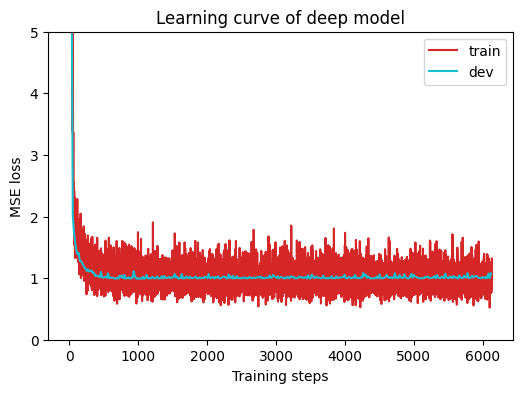

In [114]:
plot_learning_curve(model_loss_record, title='deep model')

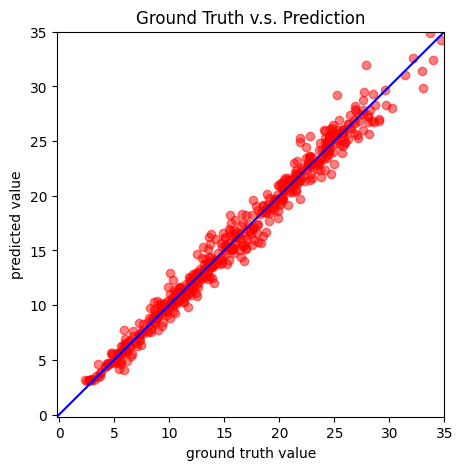

In [115]:
del model
model = NeuralNet(tr_set.dataset.dim).to(device)
ckpt = torch.load(config['save_path'], map_location='cpu')  # Load your best model
model.load_state_dict(ckpt)
plot_pred(dv_set, model, device)  # Show prediction on the validation set

# **Testing**
The predictions of your model on testing set will be stored at `pred.csv`.

In [116]:
def save_pred(preds, file):
    ''' Save predictions to specified file '''
    print('Saving results to {}'.format(file))
    with open(file, 'w') as fp:
        writer = csv.writer(fp)
        writer.writerow(['id', 'tested_positive'])
        for i, p in enumerate(preds):
            writer.writerow([i, p])

save_pred(preds, 'pred.csv')         # save prediction file to pred.csv

Saving results to pred.csv


# **Save Detail**

In [117]:
import os
import json
import shutil
from datetime import datetime

exp_id = datetime.now().strftime('%Y%m%d_%H%M%S')

os.makedirs('exp_logs', exist_ok=True)
os.makedirs('saved_models', exist_ok=True)

best_model_src = config['save_path']
best_model_dst = f'saved_models/model_{exp_id}.pth'
shutil.copy(best_model_src, best_model_dst)

exp_record = {
    'exp_id': exp_id,
    'time': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'target_only': target_only,
    'model': str(model.net),
    'config': config,
    'best_dev_loss': float(model_loss),
    'finished_epochs': len(model_loss_record['dev']),
    'saved_model': best_model_dst,
    'kaggle_score': None
}

record_path = 'exp_logs/exp_records.json'

if os.path.exists(record_path):
    with open(record_path, 'r') as f:
        records = json.load(f)
else:
    records = []

records.append(exp_record)

with open(record_path, 'w') as f:
    json.dump(records, f, indent=2, ensure_ascii=False)

print('Experiment saved to exp_logs/exp_records.json')


Experiment saved to exp_logs/exp_records.json


# **Hints**

## **Simple Baseline**
* Run sample code

## **Medium Baseline**
* Feature selection: 40 states + 2 `tested_positive` (`TODO` in dataset)

## **Strong Baseline**
* Feature selection (what other features are useful?)
* DNN architecture (layers? dimension? activation function?)
* Training (mini-batch? optimizer? learning rate?)
* L2 regularization
* There are some mistakes in the sample code, can you find them?

# **Reference**
This code is completely written by Heng-Jui Chang @ NTUEE.  
Copying or reusing this code is required to specify the original author.

E.g.  
Source: Heng-Jui Chang @ NTUEE (https://github.com/ga642381/ML2021-Spring/blob/main/HW01/HW01.ipynb)
